In [ ]:
import numpy as np
from sklearn.cluster import KMeans
from model.KMeans import kmeans

# The file uses whitespace, not commas
data = np.loadtxt(
    "data/homework_files/kmtest.csv",
    encoding="utf-8-sig"
)

k = 4

#My implementation of KMeans
my_labels, my_centroids = kmeans(data, k)

#SK-Learn's KMeans implementation for comparison
sklearn_model = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

sklearn_labels = sklearn_model.fit_predict(data)

print("My centroids:")
print(my_centroids)

print("\nScikit-learn centroids:")
print(sklearn_model.cluster_centers_)

my_inertia = np.sum(
    (data - my_centroids[my_labels]) ** 2
)

print("\nMy inertia:", my_inertia)
print("Scikit-learn inertia:", sklearn_model.inertia_)

My centroids:
[[15.5         5.        ]
 [ 9.8         9.6       ]
 [ 3.16666667  4.        ]
 [ 9.5         4.5       ]]

Scikit-learn centroids:
[[ 9.5         4.5       ]
 [15.5         5.        ]
 [ 3.16666667  4.        ]
 [ 9.8         9.6       ]]

My inertia: 18.333333333333332
Scikit-learn inertia: 18.333333333333332


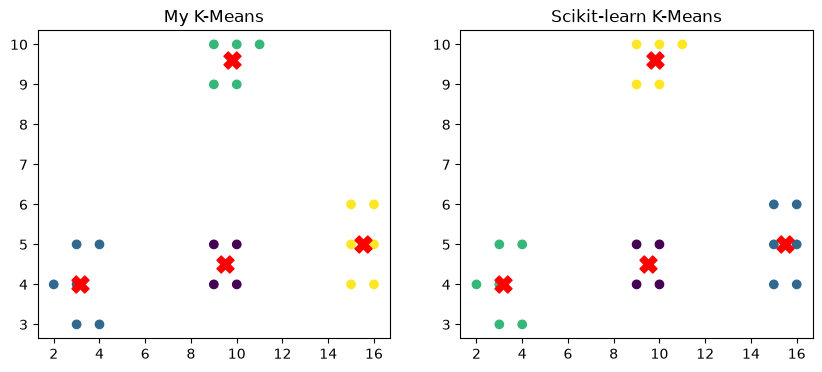

In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(data[:, 0], data[:, 1], c=my_labels)
axes[0].scatter(
    my_centroids[:, 0],
    my_centroids[:, 1],
    color="red",
    marker="X",
    s=150
)
axes[0].set_title("My K-Means")

axes[1].scatter(data[:, 0], data[:, 1], c=sklearn_labels)
axes[1].scatter(
    sklearn_model.cluster_centers_[:, 0],
    sklearn_model.cluster_centers_[:, 1],
    color="red",
    marker="X",
    s=150
)
axes[1].set_title("Scikit-learn K-Means")

plt.show()

In [8]:
import importlib
import agents.document_agent as document_agent

importlib.reload(document_agent)

chunks = document_agent.process_documents(
    "data/pdf/transformers"
)

print(len(chunks))

Processed Attention.pdf, page 1: 4 chunks
Processed Attention.pdf, page 2: 6 chunks
Processed Attention.pdf, page 3: 3 chunks
Processed Attention.pdf, page 4: 4 chunks
Processed Attention.pdf, page 5: 4 chunks
Processed Attention.pdf, page 6: 5 chunks
Processed Attention.pdf, page 7: 5 chunks
Processed Attention.pdf, page 8: 4 chunks
Processed Attention.pdf, page 9: 4 chunks
Processed Attention.pdf, page 10: 4 chunks
Processed Attention.pdf, page 11: 5 chunks
Processed Attention.pdf, page 12: 5 chunks
Processed Attention.pdf, page 13: 2 chunks
Processed Attention.pdf, page 14: 2 chunks
Processed Attention.pdf, page 15: 2 chunks
Processed Bert.pdf, page 1: 5 chunks
Processed Bert.pdf, page 2: 6 chunks
Processed Bert.pdf, page 3: 5 chunks
Processed Bert.pdf, page 4: 7 chunks
Processed Bert.pdf, page 5: 5 chunks
Processed Bert.pdf, page 6: 6 chunks
Processed Bert.pdf, page 7: 5 chunks
Processed Bert.pdf, page 8: 6 chunks
Processed Bert.pdf, page 9: 6 chunks
Processed Bert.pdf, page 10: 6 

In [9]:
from agents.document_agent import process_documents
from agents.embedding_agent import create_embeddings

In [10]:
chunks = process_documents(
    "data/pdf/transformers"
)

print("Chunks:", len(chunks))
print(chunks[0]["text"][:300])

Processed Attention.pdf, page 1: 4 chunks
Processed Attention.pdf, page 2: 6 chunks
Processed Attention.pdf, page 3: 3 chunks
Processed Attention.pdf, page 4: 4 chunks
Processed Attention.pdf, page 5: 4 chunks
Processed Attention.pdf, page 6: 5 chunks
Processed Attention.pdf, page 7: 5 chunks
Processed Attention.pdf, page 8: 4 chunks
Processed Attention.pdf, page 9: 4 chunks
Processed Attention.pdf, page 10: 4 chunks
Processed Attention.pdf, page 11: 5 chunks
Processed Attention.pdf, page 12: 5 chunks
Processed Attention.pdf, page 13: 2 chunks
Processed Attention.pdf, page 14: 2 chunks
Processed Attention.pdf, page 15: 2 chunks
Processed Bert.pdf, page 1: 5 chunks
Processed Bert.pdf, page 2: 6 chunks
Processed Bert.pdf, page 3: 5 chunks
Processed Bert.pdf, page 4: 7 chunks
Processed Bert.pdf, page 5: 5 chunks
Processed Bert.pdf, page 6: 6 chunks
Processed Bert.pdf, page 7: 5 chunks
Processed Bert.pdf, page 8: 6 chunks
Processed Bert.pdf, page 9: 6 chunks
Processed Bert.pdf, page 10: 6 

In [11]:
embeddings = create_embeddings(chunks)

print("Embedding shape:", embeddings.shape)

Embedding shape: (408, 768)


In [12]:
labels, centroids = kmeans(
    embeddings,
    k=5
)

print("Labels shape:", labels.shape)
print("Centroids shape:", centroids.shape)
print("First 10 labels:", labels[:10])
print("First 10 centroids:", centroids[:10])

Labels shape: (408,)
Centroids shape: (5, 768)
First 10 labels: [0 2 2 0 0 0 0 0 0 0]
First 10 centroids: [[-0.02744174  0.0010994  -0.00421983 ... -0.01445922 -0.02636854
  -0.00450735]
 [-0.02045771  0.01023743  0.0158415  ...  0.01244599 -0.02928405
   0.01226842]
 [-0.02183391 -0.01144067  0.01787557 ...  0.01191166 -0.02234886
   0.01530698]
 [-0.025377    0.01237294  0.00252846 ...  0.00378856 -0.03788675
   0.01793079]
 [-0.01682509 -0.00210236 -0.02145805 ...  0.00377439  0.00641364
   0.0013993 ]]


In [13]:
for chunk, label in zip(chunks, labels):
    chunk["cluster"] = int(label)

In [14]:
from agents.clustering_agent import evaluate_clusters

results = evaluate_clusters(
    embeddings,
    min_k=2,
    max_k=10
)

k=2: inertia=215.0383, silhouette=0.0500
k=3: inertia=203.3518, silhouette=0.0691
k=4: inertia=193.5791, silhouette=0.0772
k=5: inertia=185.1307, silhouette=0.0845
k=6: inertia=182.3147, silhouette=0.0830
k=7: inertia=177.5980, silhouette=0.0868
k=8: inertia=171.8225, silhouette=0.0942
k=9: inertia=168.1812, silhouette=0.0998
k=10: inertia=167.5724, silhouette=0.0861


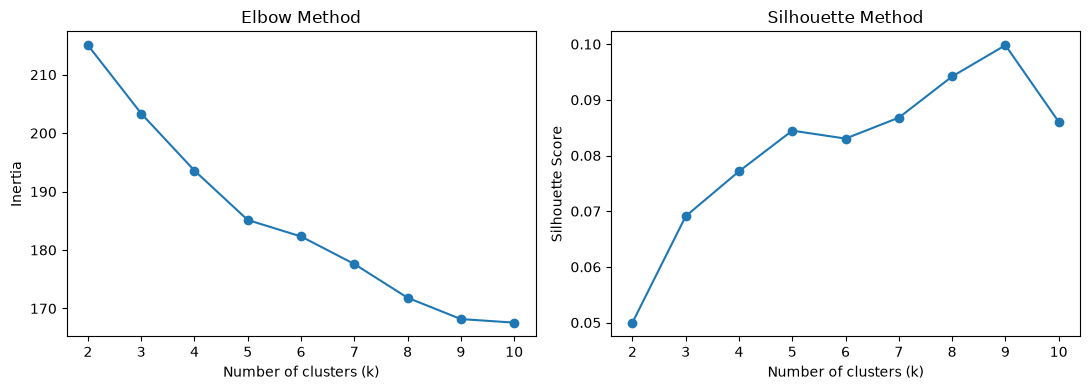

In [15]:
import matplotlib.pyplot as plt

k_values = [result["k"] for result in results]
inertias = [result["inertia"] for result in results]
silhouettes = [result["silhouette"] for result in results]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(k_values, inertias, marker="o")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method")

axes[1].plot(k_values, silhouettes, marker="o")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Method")

plt.tight_layout()
plt.show()

In [16]:
best_result = max(
    results,
    key=lambda result: result["silhouette"]
)

best_k = best_result["k"]
labels = best_result["labels"]
centroids = best_result["centroids"]

print("Recommended k:", best_k)
print("Silhouette:", best_result["silhouette"])

Recommended k: 9
Silhouette: 0.09980812653542079


In [17]:
representatives = []

for cluster_id in range(best_k):
    indices = np.where(labels == cluster_id)[0]

    cluster_embeddings = embeddings[indices]

    distances = np.sqrt(
        np.sum(
            (
                cluster_embeddings
                - centroids[cluster_id]
            ) ** 2,
            axis=1
        )
    )

    closest_position = np.argmin(distances)
    representative_index = indices[closest_position]

    representatives.append({
        "cluster": cluster_id,
        "chunk": chunks[representative_index],
    })

In [18]:
for representative in representatives:
    chunk = representative["chunk"]

    print(
        f"\n===== Cluster "
        f"{representative['cluster']} ====="
    )
    print("Source:", chunk["source"])
    print("Page:", chunk["page"])
    print(chunk["text"][:700])


===== Cluster 0 =====
Source: trillion_Params.pdf
Page: 6
of token routing dynamics. Each expert processes a ﬁxed batch-size of tokens modulated by the capacity factor. Each token is routed to the expert with the highest router probability, but each expert has a ﬁxed batch size of (total tokens / num experts)× capacity factor. If the tokens are unevenly dis- patched then certain experts will overﬂow (denoted by dotted red lines), resulting in these tokens not being processed by this layer. A larger capacity factor allevi- ates this overﬂow issue, but also increases computation and communication costs (depicted by padded white/empty slots). 2.2 Eﬃcient Sparse Routing We use Mesh-Tensorﬂow (MTF) (Shazeer et al., 2018) which is a library, with similar

===== Cluster 1 =====
Source: trillion_Params.pdf
Page: 1
instability. We address these with the introduction of the Switch Transformer. We simplify the MoE routing algorithm and design intuitive improved models with reduced communication 

In [19]:
from agents.topic_agent import create_topics

topics = create_topics(representatives)

In [20]:
for topic in topics:
    print(f"\n===== Cluster {topic['cluster']} =====")
    print("Representative source:", topic["source"])
    print("Page:", topic["page"])
    print(topic["result"])


===== Cluster 0 =====
Representative source: trillion_Params.pdf
Page: 6
Topic: Distributed Token Routing
Summary: The text discusses the dynamics of token routing, the challenges of expert overflow, and the use of Mesh-TensorFlow (MTF) for efficient sparse routing in distributed architectures.

===== Cluster 1 =====
Representative source: trillion_Params.pdf
Page: 1
Topic: Mixture-of-Experts Optimization
Summary: The paper introduces methods and models, such as the Switch Transformer, to improve the stability, efficiency, and scale of large, sparse, multilingual language models.

===== Cluster 2 =====
Representative source: Attention.pdf
Page: 10
Topic: Transformer Model Performance
Summary: The Transformer model, based entirely on attention, significantly outperforms previous sequence transduction models and achieves a new state of the art in translation tasks.

===== Cluster 3 =====
Representative source: LoRA.pdf
Page: 9
Topic: Parameter-Efficient Fine-Tuning
Summary: The text ask

In [21]:
from agents.summary_agent import create_final_summary

final_summary = create_final_summary(topics)

print("FINAL MULTI-DOCUMENT SUMMARY")
print()
print(final_summary)

FINAL MULTI-DOCUMENT SUMMARY

The field of deep learning and Natural Language Processing (NLP) is characterized by advancements in model architecture, pre-training methods, and parameter-efficient adaptation techniques.

The Transformer model, which relies entirely on the attention mechanism, has significantly outperformed previous sequence transduction models, achieving a new state of the art in translation tasks. Pre-trained representations, exemplified by models like BERT, have demonstrated that these representations reduce the need for heavily-engineered task-specific architectures in NLP by achieving state-of-the-art performance. Performance comparisons across various language models, such as BiLSTM, GPT, and BERT, are often evaluated using benchmarks like GLUE.

To manage the complexity and scale of large, sparse, multilingual language models, optimization methods are crucial. Mixture-of-Experts (MoE) optimization methods, such as the Switch Transformer, are introduced to improve